Contains Parliamentary information licensed under the [Open Parliament Licence v3.0.](https://www.parliament.uk/site-information/copyright-parliament/open-parliament-licence/)

In [1]:
import pandas as pd
from scipy import stats

## Vote share

In [2]:
elections_uk=pd.read_csv('elections_uk.csv',sep='\s+').rename(columns={'CON2':'CON','LD3':'LD'})

In [3]:
seat_colours={'CON':'tab:blue',
              'LAB':'tab:red',
              'LD':'tab:orange',
              'PC/SNP':'y',
              'Other':'tab:purple'}

<AxesSubplot: xlabel='date'>

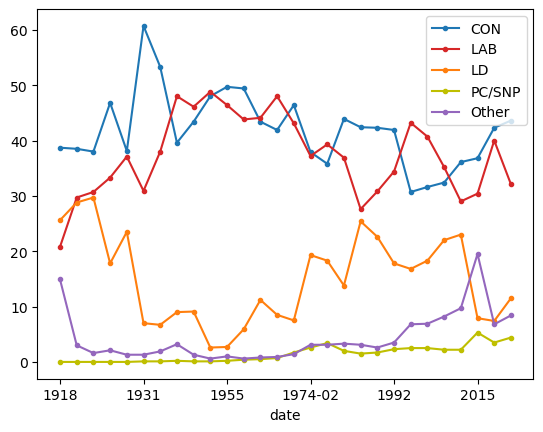

In [4]:
elections_uk.set_index('date').plot(marker='.',color=seat_colours)

1918 is an outlier because it predates Irish independence. While the Irish were considered UK voters, they mostly voted as a nationalist block. Strictly speaking it should be excluded, or at least included with PC/SNP nationalists. 

Note that the "Representation of the People" act of 1918 gives voting rights to all men above 21 years old but only to some women, full equality of women when it comes to voting only happens with the 1928 act. The consequences of that are less clear in the data, which shows a drop for the liberals and an increase for the conservatives at this time.

In [5]:
elections_uk.set_index('date').drop(columns=['Total']).corr()

,CON,LAB,LD,PC/SNP,Other
CON,1.000000,0.124893,-0.587448,-0.430400,-0.473085
LAB,0.124893,1.000000,-0.681089,-0.166812,-0.516683
LD,-0.587448,-0.681089,1.000000,-0.025856,0.178277
PC/SNP,-0.430400,-0.166812,-0.025856,1.000000,0.608985
Other,-0.473085,-0.516683,0.178277,0.608985,1.000000


array([[<AxesSubplot: xlabel='CON', ylabel='CON'>,
        <AxesSubplot: xlabel='LAB', ylabel='CON'>,
        <AxesSubplot: xlabel='LD', ylabel='CON'>,
        <AxesSubplot: xlabel='PC/SNP', ylabel='CON'>,
        <AxesSubplot: xlabel='Other', ylabel='CON'>],
       [<AxesSubplot: xlabel='CON', ylabel='LAB'>,
        <AxesSubplot: xlabel='LAB', ylabel='LAB'>,
        <AxesSubplot: xlabel='LD', ylabel='LAB'>,
        <AxesSubplot: xlabel='PC/SNP', ylabel='LAB'>,
        <AxesSubplot: xlabel='Other', ylabel='LAB'>],
       [<AxesSubplot: xlabel='CON', ylabel='LD'>,
        <AxesSubplot: xlabel='LAB', ylabel='LD'>,
        <AxesSubplot: xlabel='LD', ylabel='LD'>,
        <AxesSubplot: xlabel='PC/SNP', ylabel='LD'>,
        <AxesSubplot: xlabel='Other', ylabel='LD'>],
       [<AxesSubplot: xlabel='CON', ylabel='PC/SNP'>,
        <AxesSubplot: xlabel='LAB', ylabel='PC/SNP'>,
        <AxesSubplot: xlabel='LD', ylabel='PC/SNP'>,
        <AxesSubplot: xlabel='PC/SNP', ylabel='PC/SNP'>,
       

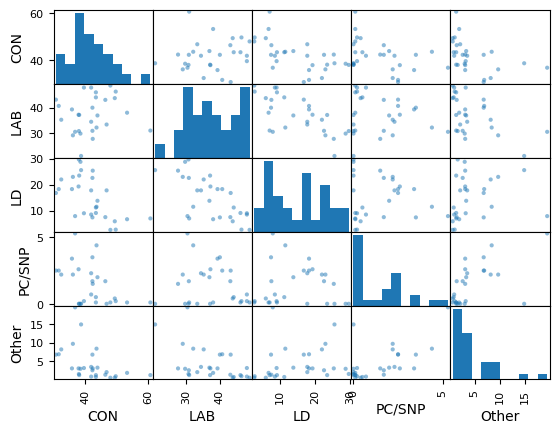

In [6]:
pd.plotting.scatter_matrix(elections_uk.set_index('date').drop(columns=['Total']))

## Seats won

In [7]:
elections_seats=pd.read_csv('seats.csv')#,sep='\s+'

In [8]:
elections_seats

,CON,LAB,LD,PC/SNP,Other,Total
1918,382,57,163,0,105,707
1922,344,142,115,0,14,615
1923,258,191,158,0,8,615
1924,412,151,40,0,12,615
1929,260,287,59,0,9,615
1931,522,52,36,0,5,615
1935,429,154,21,0,11,615
1945,210,393,12,0,25,640
1950,298,315,9,0,3,625
1951,321,295,6,0,3,625


<AxesSubplot: ylabel='seats'>

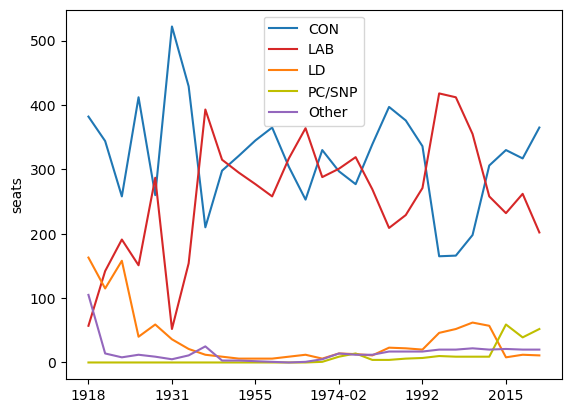

In [9]:
elections_seats.drop(columns=['Total']).plot(color=seat_colours, ylabel='seats')

Note in 1997 not only the labour landslide but also the increase of Lib Dems as the 3rd party. They will swap this position with SNP from 2015, the first election following their time in coalition government.

In [10]:
elections_seats.drop(columns=['Total']).corr()

,CON,LAB,LD,PC/SNP,Other
CON,1.000000,-0.854832,-0.080620,-0.025031,0.027421
LAB,-0.854832,1.000000,-0.422792,0.004031,-0.337041
LD,-0.080620,-0.422792,1.000000,-0.228671,0.577374
PC/SNP,-0.025031,0.004031,-0.228671,1.000000,0.105035
Other,0.027421,-0.337041,0.577374,0.105035,1.000000


array([[<AxesSubplot: xlabel='CON', ylabel='CON'>,
        <AxesSubplot: xlabel='LAB', ylabel='CON'>,
        <AxesSubplot: xlabel='LD', ylabel='CON'>,
        <AxesSubplot: xlabel='PC/SNP', ylabel='CON'>,
        <AxesSubplot: xlabel='Other', ylabel='CON'>],
       [<AxesSubplot: xlabel='CON', ylabel='LAB'>,
        <AxesSubplot: xlabel='LAB', ylabel='LAB'>,
        <AxesSubplot: xlabel='LD', ylabel='LAB'>,
        <AxesSubplot: xlabel='PC/SNP', ylabel='LAB'>,
        <AxesSubplot: xlabel='Other', ylabel='LAB'>],
       [<AxesSubplot: xlabel='CON', ylabel='LD'>,
        <AxesSubplot: xlabel='LAB', ylabel='LD'>,
        <AxesSubplot: xlabel='LD', ylabel='LD'>,
        <AxesSubplot: xlabel='PC/SNP', ylabel='LD'>,
        <AxesSubplot: xlabel='Other', ylabel='LD'>],
       [<AxesSubplot: xlabel='CON', ylabel='PC/SNP'>,
        <AxesSubplot: xlabel='LAB', ylabel='PC/SNP'>,
        <AxesSubplot: xlabel='LD', ylabel='PC/SNP'>,
        <AxesSubplot: xlabel='PC/SNP', ylabel='PC/SNP'>,
       

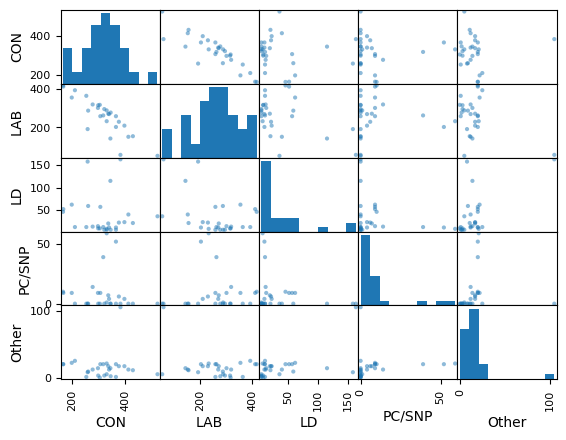

In [11]:
pd.plotting.scatter_matrix(elections_seats.drop(columns=['Total']))

## Effect of electoral system

<AxesSubplot: xlabel='CON', ylabel='LAB'>

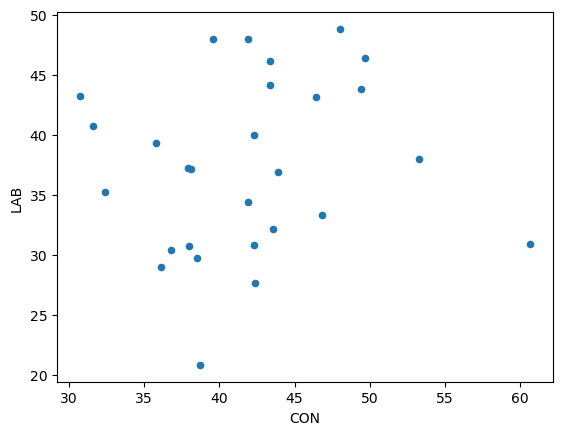

In [12]:
elections_uk.plot(kind='scatter',x='CON',y='LAB')

In [13]:
stats.pearsonr(elections_uk.CON,elections_uk.LAB)

PearsonRResult(statistic=0.12489254401884041, pvalue=0.5265862615032864)

<AxesSubplot: xlabel='CON', ylabel='LAB'>

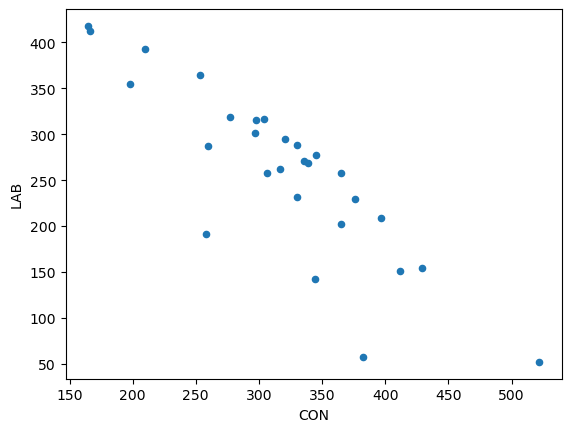

In [14]:
elections_seats.plot(kind='scatter',x='CON',y='LAB')

Unlike the votes, the total seats will obey a fixed relationship  
$y_{LAB}=c_{TOT}-x_{CON}-z_{other}$  
The other parties share is not random noise and that's where the linear model of the Labour/Conservative relationship breaks down, but if it is small enough then it is less of a problem.

In [15]:
stats.pearsonr(elections_seats.CON,elections_seats.LAB)

PearsonRResult(statistic=-0.8548319993076484, pvalue=7.00047624027453e-09)

In [16]:
elections_seats[['CON','LAB']].nlargest(columns='LAB',n=2)

,CON,LAB
1997,165,418
2001,166,412


In [17]:
elections_seats[['CON','LAB']].nsmallest(columns='LAB',n=2)

,CON,LAB
1931,522,52
1918,382,57


In [18]:
(elections_uk
 .set_index('date')
 .loc['1983']
)

CON       42.4
LAB       27.6
LD        25.4
PC/SNP     1.5
Other      3.1
Total     100%
Name: 1983, dtype: object

In [19]:
(elections_seats
 .loc['1983']
)

CON       397
LAB       209
LD         23
PC/SNP      4
Other      17
Total     650
Name: 1983, dtype: int64

## Regression

In [20]:
con_lab_regress=stats.linregress(elections_seats.CON,elections_seats.LAB)

In [21]:
con_lab_regress

LinregressResult(slope=-1.0035078135833235, intercept=578.9723770185267, rvalue=-0.8548319993076486, pvalue=7.000476240274454e-09, stderr=0.1194651000346639, intercept_stderr=39.10535837323708)

In [22]:
elections_seats_err=(elections_seats
  .assign(lab_predicted=elections_seats.CON*con_lab_regress.slope+con_lab_regress.intercept,
     residuals_no_out=elections_seats.LAB-(elections_seats.CON*con_lab_regress.slope+con_lab_regress.intercept),
     low_err=lambda df: df.residuals_no_out.where(df.residuals_no_out<0,0).abs(),
     high_err=lambda df: df.residuals_no_out.where(df.residuals_no_out>=0,0)
        )
)

<AxesSubplot: xlabel='CON', ylabel='LAB'>

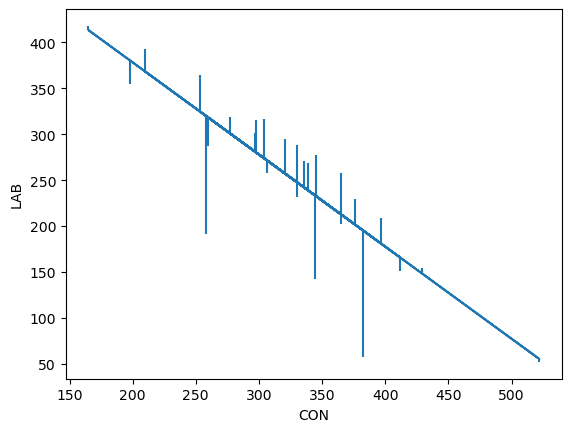

In [23]:
(elections_seats_err
 .reset_index()
 .set_index('CON')
 .lab_predicted
 .plot(yerr=[elections_seats_err.reset_index().set_index('CON')['low_err'],
       elections_seats_err.reset_index().set_index('CON')['high_err']],
       ylabel='LAB'
      )
)

<AxesSubplot: >

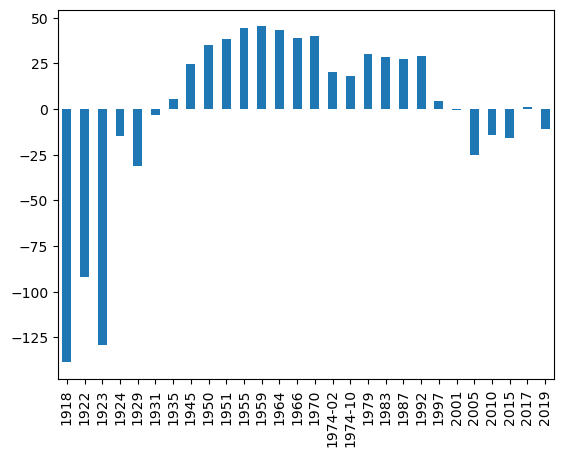

In [24]:
elections_seats_err.residuals_no_out.plot(kind='bar')

In [27]:
elections_seats_err.residuals_no_out.nlargest(n=5)

1959    45.307975
1955    44.237819
1964    43.093998
1970    40.185201
1966    38.915100
Name: residuals_no_out, dtype: float64

In [28]:
elections_seats_err.residuals_no_out.nsmallest(n=5)

1918   -138.632392
1923   -129.067361
1922    -91.765689
1929    -31.060345
2005    -25.277830
Name: residuals_no_out, dtype: float64

## Regression without initial outliers

In [29]:
con_lab_regress_no_out=stats.linregress(elections_seats.loc['1924':,'CON'],elections_seats.loc['1924':,'LAB'])

In [30]:
con_lab_regress_no_out

LinregressResult(slope=-0.9789096137621255, intercept=585.5602528707404, rvalue=-0.9590264806407451, pvalue=4.3179075245309837e-14, stderr=0.06030035433937967, intercept_stderr=19.70397098851467)

In [31]:
elections_seats_enhanced=(elections_seats
 .assign(lab_predicted=elections_seats.CON*con_lab_regress_no_out.slope+con_lab_regress_no_out.intercept,
     residuals_no_out=elections_seats.LAB-(elections_seats.CON*con_lab_regress_no_out.slope+con_lab_regress_no_out.intercept),
     low_err=lambda df: df.residuals_no_out.where(df.residuals_no_out<0,0).abs(),
         high_err=lambda df: df.residuals_no_out.where(df.residuals_no_out>=0,0)
        )
 .loc['1924':]
)

<AxesSubplot: xlabel='CON', ylabel='LAB'>

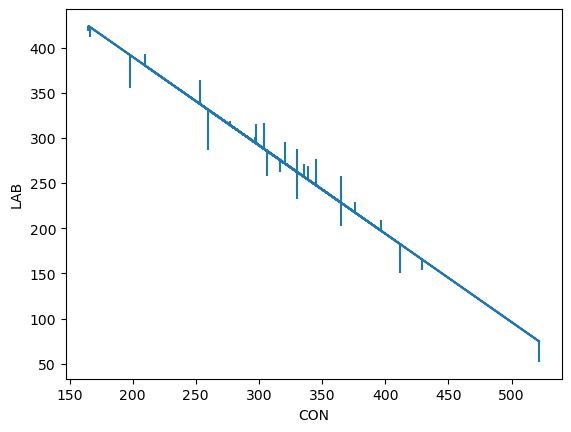

In [32]:
(elections_seats_enhanced
 .reset_index()
 .set_index('CON')
 .lab_predicted
 .plot(yerr=[elections_seats_enhanced.reset_index().set_index('CON')['low_err'],
       elections_seats_enhanced.reset_index().set_index('CON')['high_err']],
       ylabel='LAB'
      )
)

<AxesSubplot: >

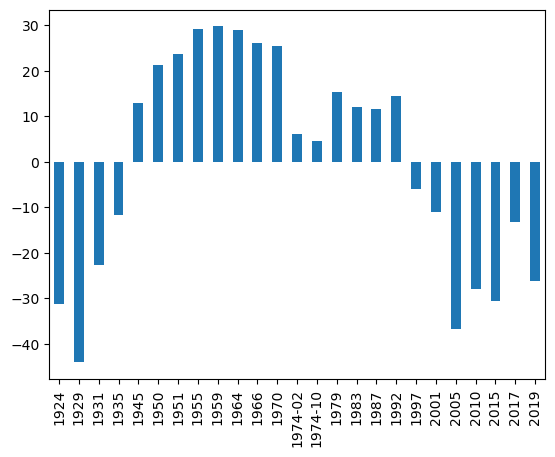

In [33]:
elections_seats_enhanced.residuals_no_out.plot(kind='bar')

On one hand the residuals are not random and prove that linear regression is kind of wrong for this data. On the other hand the residuals show the different phases of political history:
- before World War II
- Change in sign after the War, up to the 1973 oil crisis
- near zero for the elections in the immediate aftermath of the crisis in 1974
- bigger positive values again for the Thatcherist years 1979-1992
- change in sign from New Labour's victory in 1997
- a small negative value in the first election after the Brexit referendum

Though the dataset doesn't extend enough after that to identify the next cluster.

In [34]:
(elections_seats_enhanced
       .reset_index()
       .set_index('CON')
       [['low_err','high_err']]
)

,low_err,high_err
CON,,
412,31.249492,0.000000
260,44.043753,0.000000
522,22.569434,0.000000
429,11.608029,0.000000
210,0.000000,13.010766
298,0.000000,21.154812
321,0.000000,23.669733
345,0.000000,29.163564
365,0.000000,29.741756
